<a href="https://colab.research.google.com/github/nandakishorea2004/svm-classification/blob/main/svm_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Load the dataset
df = pd.read_csv("SVM DATA.csv", encoding='ISO-8859-1')

In [ ]:
# Rename the target column to a simple name
df = df.rename(columns={'|G*|   / sin ?': 'target'})

In [ ]:
df['target_class'] = pd.qcut(df['target'], q=3, labels=['low', 'medium', 'high'])

In [ ]:
X = df.drop(['target', 'target_class'], axis=1)
y = df['target_class']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Train SVM
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
# Predict and evaluate
y_pred = svm.predict(X_test)

In [ ]:

print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.82


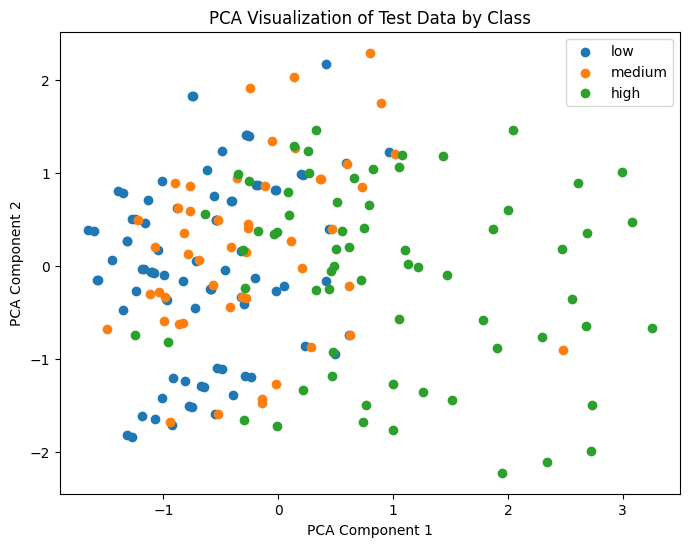

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

plt.figure(figsize=(8,6))
for label in ['low', 'medium', 'high']:
    plt.scatter(X_test_pca[y_test == label, 0], X_test_pca[y_test == label, 1], label=label)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA Visualization of Test Data by Class')
plt.legend()
plt.show()

# Task
Explain the error in the selected code. If possible, fix the error and incorporate the changes into the existing code. Otherwise, try to diagnose the error.

## Inspect column names

### Subtask:
Print the column names of the DataFrame to identify the exact name of the target variable.


**Reasoning**:
The error message indicates that the column name provided in the `df.drop()` call was not found. Printing the column names will help identify the correct column name for the target variable.



In [ ]:
print(df.columns)

In [ ]:
X = df.drop('|G*|   / sin ?', axis=1)
y = df['|G*|   / sin ?']

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Create and train the SVM classifier with the discretized target
svm = SVC(kernel='linear')
svm.fit(X_train_scaled, y_train_discretized)

In [ ]:
# Predict on the test set
y_pred_discretized = svm.predict(X_test_scaled)

# Evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test_discretized, y_pred_discretized))
print("\nClassification Report:\n", classification_report(y_test_discretized, y_pred_discretized))
print("Accuracy Score:", accuracy_score(y_test_discretized, y_pred_discretized))